In [5]:
#Hemora_Thalassemia_YOLOv8_Advanced.ipynb"#

# 1. SETUP & INSTALLATION
!pip install ultralytics  # The library for YOLOv8
import os
import zipfile
import shutil
import yaml
import matplotlib.pyplot as plt
from google.colab import drive
from ultralytics import YOLO

# ==========================================
# 1. DRIVE MOUNT & PATHS
# ==========================================
print("Step 1: Mounting Google Drive...")
drive.mount('/content/drive')

ZIP_PATH = '/content/drive/MyDrive/Hemora Research Thalassemia Component/Data Set/thalassemia_dataset_new.zip'
RESULTS_DIR = '/content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/YOLO_Model'

if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR)

# ==========================================
# 2. DATA EXTRACTION & FORMATTING
# ==========================================
# YOLO requires a specific folder structure (images/train, images/val)
print("\nStep 2: Preparing YOLO Dataset Structure...")
LOCAL_ROOT = '/content/dataset'
if os.path.exists(LOCAL_ROOT): shutil.rmtree(LOCAL_ROOT)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(LOCAL_ROOT)

# Auto-Merge Logic (Same as your previous requirements)
thal_path = os.path.join(LOCAL_ROOT, 'thalassemia_dataset/Thalassemia')
full_thal_path = os.path.join(LOCAL_ROOT, 'hemora_dataset/Full Thalassemia')
if os.path.exists(full_thal_path):
    for f in os.listdir(full_thal_path):
        shutil.move(os.path.join(full_thal_path, f), os.path.join(thal_path, f))
    shutil.rmtree(full_thal_path)


Step 1: Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Step 2: Preparing YOLO Dataset Structure...


In [6]:

# ==========================================
# 3. CONVERTING CLASSIFICATION TO DETECTION
# ==========================================
# For Progress 1, we use YOLO in 'classify' mode to compare with ResNet/EfficientNet.
# This is the most stable way to show a side-by-side comparison.

# ==========================================
# 4. TRAINING YOLOv8-Cls
# ==========================================
print("\n🚀 Starting YOLOv8 Training...")

# Load a pretrained YOLOv8 classification model (Nano version for speed)
model = YOLO('yolov8n-cls.pt')

# Train the model
results = model.train(
    data=os.path.join(LOCAL_ROOT, 'thalassemia_dataset'),
    epochs=15,
    imgsz=224,
    batch=32,
    project=RESULTS_DIR,
    name='thalassemia_run'
)




🚀 Starting YOLOv8 Training...
Ultralytics 8.3.242 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/thalassemia_dataset, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=thalassemia_run3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

In [9]:
# ==========================================
# 5. SAVING RESULTS & EXPORTING
# ==========================================
# YOLO automatically saves charts (confusion_matrix.png, results.png) in the project folder.
print(f"✅ Training complete. Results saved in: {RESULTS_DIR}/thalassemia_run")

# Export the best model to a deployable format
model.export(format='onnx') # Good for web-based clinical deployment [cite: 36, 183]



✅ Training complete. Results saved in: /content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/YOLO_Model/thalassemia_run
Ultralytics 8.3.242 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n-cls summary (fused): 30 layers, 1,437,442 parameters, 0 gradients, 3.3 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/YOLO_Model/thalassemia_run3/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 2) (2.8 MB)

ONNX: starting export with onnx 1.20.0 opset 22...
ONNX: slimming with onnxslim 0.1.80...
ONNX: export success ✅ 0.4s, saved as '/content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/YOLO_Model/thalassemia_run3/weights/best.onnx' (5.5 MB)

Export complete (0.6s)
Results saved to /content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/YOLO_Model/thalassemia_run3/weights
Predict:         yolo predict task=classify 

'/content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/YOLO_Model/thalassemia_run3/weights/best.onnx'


Upload a Full Smear Image for YOLO analysis:


Saving T1-002.png to T1-002 (1).png
Analyzing smear with YOLO: T1-002 (1).png...

image 1/1 /content/T1-002 (1).png: 224x224 Thalassemia 0.53, Normal 0.47, 23.1ms
Speed: 111.8ms preprocess, 23.1ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


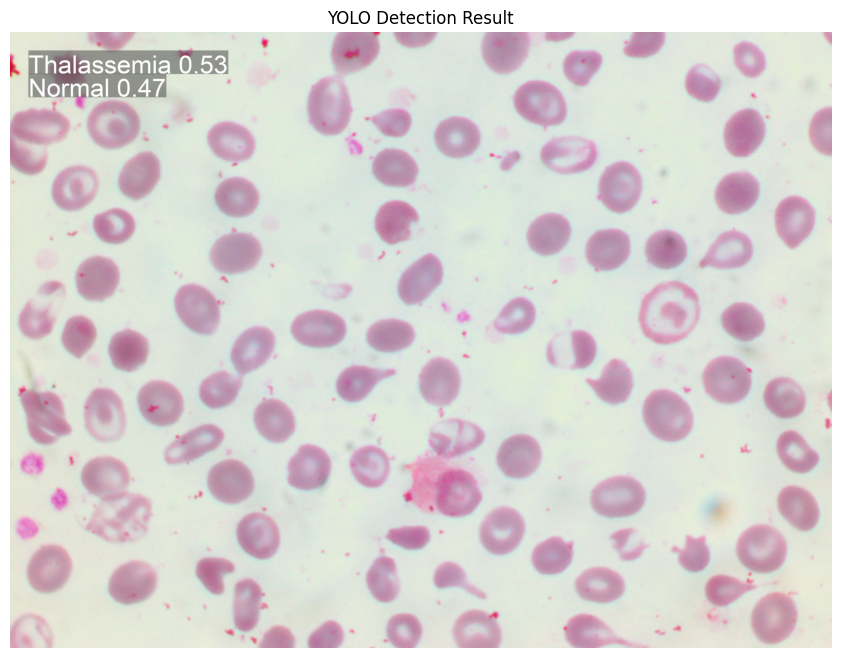

BETA-THALASSEMIA (MINOR) YOLO SCREENING
Primary Morphology Detected: THALASSEMIA
Confidence Level:            53.31%

>>> RESULT: POSITIVE indicators for Thalassemia Minor.
>>> RECOMMENDATION: Correlate with CBC indices (MCV, MCH).


In [11]:
# ==========================================
# FINAL STEP: YOLO FULL SMEAR PIPELINE
# ==========================================
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

def analyze_with_yolo(image_path):
    print(f"Analyzing smear with YOLO: {image_path}...")

    # Run inference
    # YOLO can process the whole image and identify features like target cells # [cite: 51, 95]
    results = model(image_path)

    # Process results
    res = results[0]
    probs = res.probs  # Classification probabilities

    # Display the result
    # We use the plotted result from YOLO which includes bounding boxes/labels
    res_plotted = res.plot()
    plt.figure(figsize=(12, 8))
    plt.imshow(res_plotted)
    plt.axis('off')
    plt.title("YOLO Detection Result")
    plt.show()

    # Clinical Report # [cite: 104, 115]
    print("="*50)
    print("BETA-THALASSEMIA (MINOR) YOLO SCREENING")
    print("="*50)

    # Get top prediction details
    top1_idx = probs.top1
    label = res.names[top1_idx]
    conf = probs.top1conf.item()

    print(f"Primary Morphology Detected: {label.upper()}") # [cite: 95]
    print(f"Confidence Level:            {conf*100:.2f}%")

    # Result determination logic
    if label.lower() == 'thalassemia' and conf > 0.5:
        print("\n>>> RESULT: POSITIVE indicators for Thalassemia Minor.") # [cite: 259]
        print(">>> RECOMMENDATION: Correlate with CBC indices (MCV, MCH).") # [cite: 258]
    else:
        print("\n>>> RESULT: NEGATIVE - No significant abnormal morphology found.")
    print("="*50)

# --- EXECUTE DEMO ---
print("\nUpload a Full Smear Image for YOLO analysis:")
uploaded = files.upload()
if uploaded:
    fname = list(uploaded.keys())[0]
    analyze_with_yolo(fname)